In [1]:
#import scarches as sca
#import torch
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import os
import time
import pickle
from itertools import chain
import itertools
from tqdm.auto import tqdm
from adjustText import adjust_text
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# LOAD DATA

In [3]:
ref_genomes=['GRCh38-p14-Gencode_v44','GRCh38-p13-Gencode_v33']

adata_dict={}
for ref_genome in ref_genomes[:1]:
    #fn=f'{proc_dir}/{ref_genome}_filtered_batch_corrected_clustered_annotated.h5ad'
    fn=f'{proc_dir}/{ref_genome}_with_intron_filtered_batch_corrected_clustered_annotated.h5ad'
    adata=sc.read_h5ad(fn)

    #adata.obs['final_high_level_celltype'] = adata.obs['final_high_level_celltypes'].values
    #adata.obs['final_low_level_celltype'] = adata.obs['final_low_level_celltypes'].values

    #adata.obs=adata.obs.drop(columns=['final_high_level_celltypes','final_low_level_celltypes'])

    adata_dict[ref_genome]=adata

# ADD METADATA OF PATIENTS

In [4]:
## Load metadata
metadata=pd.read_excel('../../../data/ScSeq_Patinfo1-17_toextern_18062024_NS-MVB.xlsx',
                       index_col=0,skiprows=[0]) 

## CREATE column with mathcing pat id values as in the anndata + shorten some column names
#metadata['condition']=metadata['sample_id'].str.split('_',expand=True)[1]
metadata['pat_id']=[id.replace(' ','') for id in metadata.index]
metadata['Symptomatic']=metadata['Symptomatic (a/s)'].replace({'a':'asympt.','s':'sympt.'},regex=True).values
metadata['Stability']=metadata['stability (+/-)'].replace({'+':'stable','-':'unstable'}).values
metadata['Symptoms']=metadata['Symptoms (AF: Amaourosis fugax ipsilateral; TIA: Transitorischen Ischämischen Attacke; MCA-I:middle cerebral artery infarct)'].replace({'-':np.nan}).values


metadata['rupture (+/-)'] = metadata['rupture (+/-)'].astype(str).str.strip()
metadata['Rupture']=metadata['rupture (+/-)'].replace({'+':'yes','-':'no','?':np.nan,'+?':'yes'},regex=False).values
metadata['Stenosis_perc']=metadata['% of stenosis (NASCET)']
metadata['Size']=metadata['Size (cm)']
metadata['Weight']=metadata['Weight (kg)']
metadata['Smoking_ever']=metadata['Smoking'].replace({'ex':'yes'})
metadata['AHA_class.']=metadata['AHA classification'].replace({'III':3,'V':5,'VI':6,'VI/VII':6.5})
metadata['ASA_stadium']=metadata['ASA Stadium'].astype(str)


metadata=metadata.set_index('pat_id',drop=True)


for ref_genome in ref_genomes[:1]:
    print(ref_genome)
    adata=adata_dict[ref_genome]

    #metadata=metadata.set_index('pat_id',drop=False)
    for meta_coln in ['Age', 'Sex', 'Symptomatic', 'Stability', 'Rupture', 'Stenosis_perc', 'Size',
                       'Weight', 'Smoking_ever', 'AHA_class.','Hypertension', 'Diabetes', 'Smoking',
                       'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation',
                       'PAD', 'ASA Stadium','ASA_stadium','Statin','Symptoms']:
        
        mat_coln_dict=metadata[meta_coln].to_dict()
        adata.obs[meta_coln]=adata.obs['patient'].map(mat_coln_dict)

    adata_dict[ref_genome]=adata

GRCh38-p14-Gencode_v44


In [ ]:
metadata[['Symptomatic','Symptoms (AF: Amaourosis fugax ipsilateral; TIA: Transitorischen Ischämischen Attacke; MCA-I:middle cerebral artery infarct)']]

In [8]:
for col in ['Age', 'Sex', 'Symptomatic', 'Stability', 'Rupture', 'Stenosis_perc', 'Size',
                       'Weight', 'Smoking_ever', 'AHA_class.','Hypertension', 'Diabetes', 'Smoking',
                       'Dyslipidemia', 'CHD', 'Myocardial infarction', 'Atrial fibrillation',
                       'PAD', 'ASA Stadium','ASA_stadium','Statin','Symptoms']:
    print(col,metadata[col].unique())

Age [70 72 74 81 71 80 78 69 82 79 50 75 61]
Sex ['male' 'female']
Symptomatic ['asympt.' 'sympt.']
Stability ['stable' 'unstable']
Rupture ['no' nan 'yes']
Stenosis_perc [81. 90. 50. 80. 60. 85. nan 75. 95. 65.]
Size [167. 160. 176.  nan 179. 174. 170. 165. 173. 192.]
Weight [ 60  49 100  72  83  90 102  70  80  79  56  73  75]
Smoking_ever ['yes' 'no']
AHA_class. [5.  6.  3.  6.5]
Hypertension ['yes' 'no']
Diabetes ['no' 'yes']
Smoking ['ex' 'yes' 'no']
Dyslipidemia ['yes' 'no']
CHD ['no' 'yes']
Myocardial infarction ['no' nan 'yes']
Atrial fibrillation ['no' 'yes']
PAD ['no' 'yes']
ASA Stadium [2 3 1]
ASA_stadium ['2' '3' '1']
Statin ['yes' 'no']
Symptoms [nan 'AF' 'TIA' 'MCA-I']


# CELL HIGH-LEVEL CELL COUNTS/PROPORTIONS

## scRNA-seq

### Fig.2

GRCh38-p14-Gencode_v44


/tmp/ipykernel_11987/3010273156.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


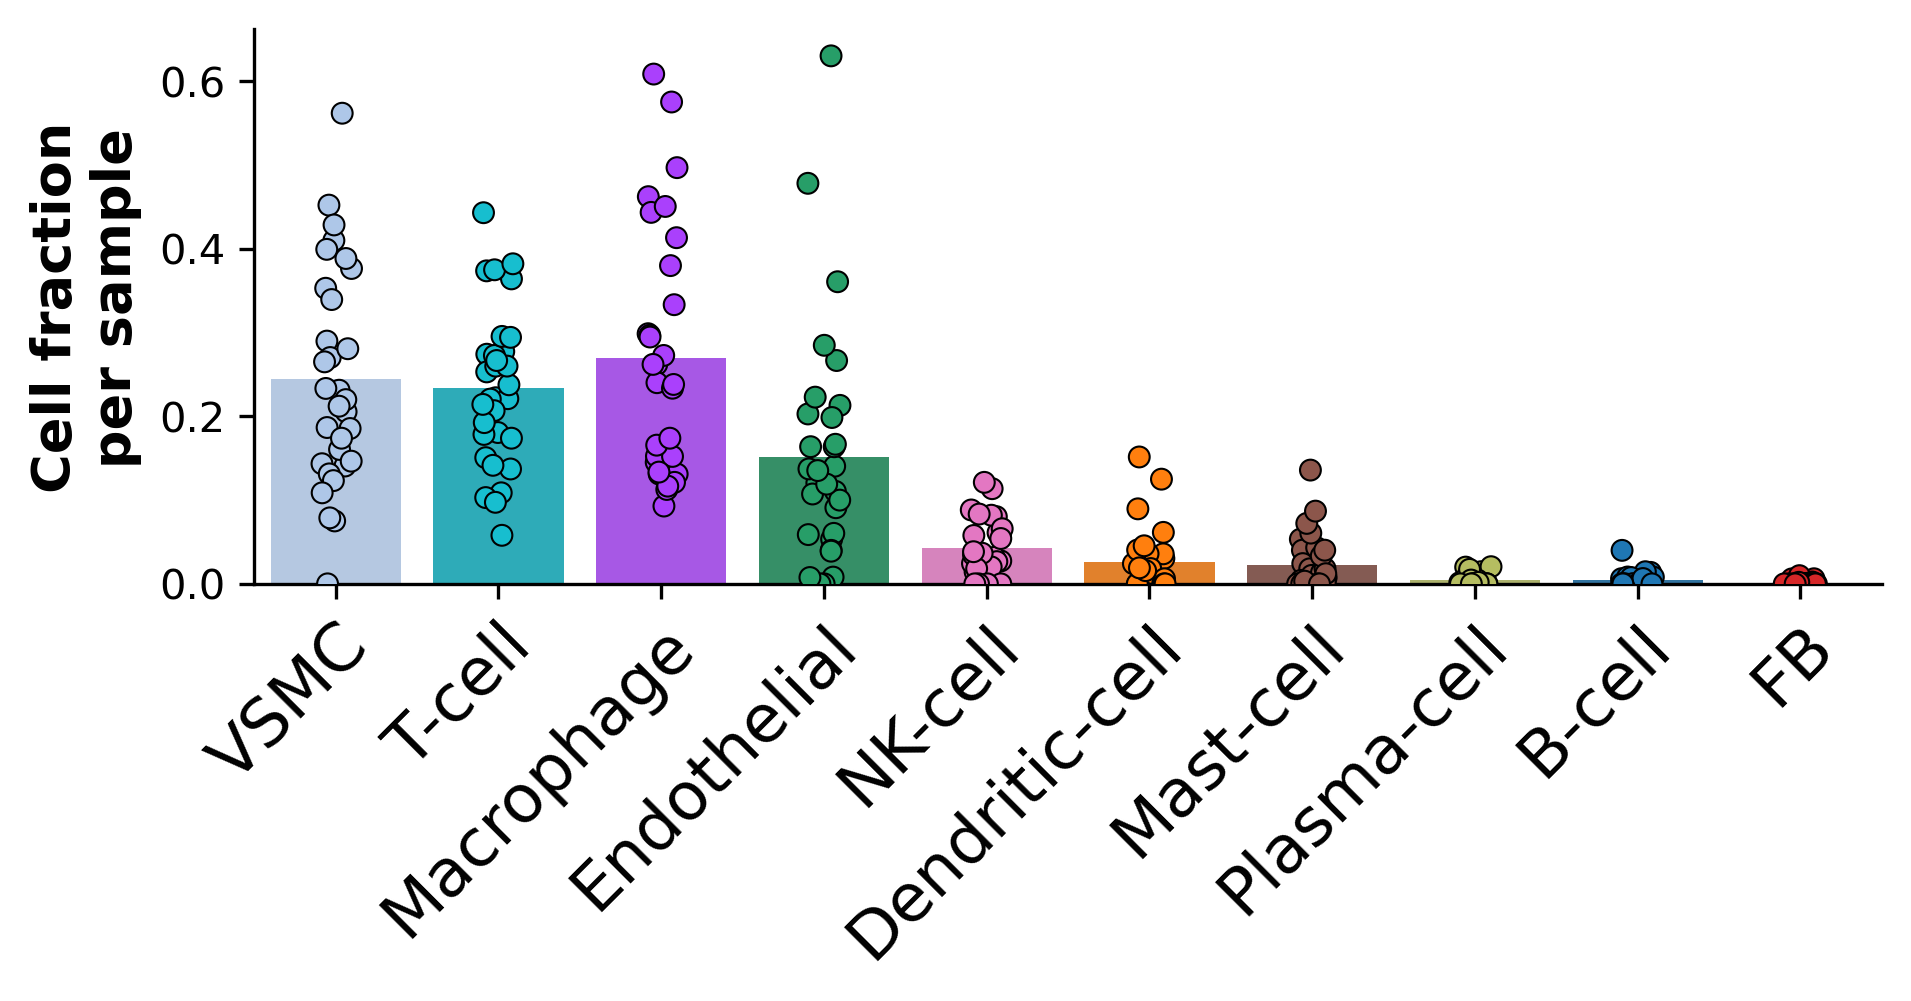

In [15]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300


color_palette={'B-cell':(31,119,180,255),
               'Dendritic-cell':(255,127,14,255),
               'Endothelial':(39,158,104,255),
               'FB':(214,39,40,255),
               'Macrophage':(170,64,252,255),
               'Mast-cell':(140,86,75,255),
               'NK-cell':(227,119,194,255),
               'Plasma-cell':(181,189,97,255),
               'T-cell':(23,190,207,255),
               'VSMC':(174,199,232,255)
              }

color_palette= {cellt:tuple(ti/255 for ti in rgba)for cellt,rgba in color_palette.items()}


for ref_genome in ref_genomes[:1]:
    print(ref_genome)
    adata=adata_dict[ref_genome]


    for cellt_coln in  ['final_high_level_celltype','final_low_level_celltype'][:1]:
        '''
        l=[]
        for scale_param in ['5','10','15','5|10|15'][:-1]:
            adata_subs=adata_dict_[scale_param][panel]
            adata_subs.obs['Scale parameter']=scale_param
    
            abs_counts=adata_subs.obs[cellt_coln].value_counts()
            norm_counts=adata_subs.obs[cellt_coln].value_counts(normalize=True)
            count_df=pd.concat([abs_counts,norm_counts],axis=1)
            count_df['Scale parameter']=scale_param
            l.append(count_df)
        
        '''
        #hue_order=adata.obs[cellt_coln].value_counts().index.tolist()
        hue_order=['VSMC', 'T-cell', 'Macrophage', 'Endothelial', 'NK-cell', 'Dendritic-cell', 'Mast-cell', 'Plasma-cell','B-cell','FB']
        #norm_counts=adata.obs[cellt_coln].value_counts(normalize=True)
        abs_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=False))#.reset_index()
        norm_counts = adata.obs.groupby('original_sample').apply(lambda x:x[cellt_coln].value_counts(normalize=True))#.reset_index()
        plot_df=pd.concat([abs_counts,norm_counts],axis=1)
        cond_df = adata.obs[['condition','original_sample']].drop_duplicates('original_sample').set_index('original_sample')
        plot_df['condition']=cond_df.loc[plot_df.reset_index()['original_sample'],'condition'].values


    
        
        met_colnames=['count','proportion'][1:]
        met_coln_titles=['Cell count','Cell fraction\n per sample'][1:]
        #print(plot_df)
        
        
        for met_coln_title,met_coln in zip(met_coln_titles,met_colnames):

            fig,ax=plt.subplots(1,1,figsize=(7,2.4))
            #fig.suptitle('scRNA-seq',fontsize=14,fontweight='bold')
    
            sns.barplot(data=plot_df.reset_index(),
                        x=cellt_coln,
                        y=met_coln,color='dodgerblue',#alpha=0.7,
                        order=hue_order,
                        errorbar=None,
                        palette=color_palette)
            
            sns.stripplot(data=plot_df,
                         x=cellt_coln,
                        y=met_coln,color='dodgerblue',
                          #alpha=0.7,
                        order=hue_order,
                         edgecolor='black',
                          #hue='condition',
                          linewidth=0.5,
                         palette=color_palette,
                          #palette='Set2',
                         )
    
            #ax.set_ylim(None,np.quantile(plot_df[met_coln],1))
            
            # Rotate x-axis tick labels by 45 degrees
            x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
            x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
            ax.set_xticklabels(x_ticks)
            plt.xticks(rotation=45,fontsize=16,ha='right', rotation_mode='anchor')
            #ax.tick_params(axis='x',labelsize=16,labelrotation=45,ha='right', rotation_mode='anchor')

            ax.set_ylabel(met_coln_title,fontsize=13,fontweight='bold')
            ax.set_xlabel(None)
            ax.spines[['top','right']].set_visible(False)
       
  
            ## SAvefig    
            proc_dir='../../xenium_data/processed_data/baysor_processed_output'
            os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_counts'),exist_ok=True)
            fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_counts',f'{ref_genome}_{cellt_coln}_{met_coln}_cell_counts.png')
            fig.savefig(fn, dpi=300, bbox_inches='tight')


### Mean  per-sample cell type fractions

In [22]:
for cellt in plot_df.index.get_level_values('final_high_level_celltype').unique():
    print(cellt,plot_df.loc[plot_df.index.get_level_values('final_high_level_celltype')==cellt,'proportion'].mean()*100)

plot_df.reset_index()['original_sample'].unique()

T-cell 23.34445338970194
Macrophage 26.936302415735057
Endothelial 15.099641864541674
VSMC 24.426188817467175
NK-cell 4.299933843195779
Dendritic-cell 2.605846089688112
Plasma-cell 0.5117787407179902
B-cell 0.4118952005232334
FB 0.0835589592018027
Mast-cell 2.280400679227237


['CAR1_D', 'CAR2_D', 'CAR2_H', 'CAR3_D', 'CAR3_H', ..., 'CAR15_D', 'CAR15_H', 'CAR16_D', 'CAR16_H', 'CAR17_D']
Length: 31
Categories (31, object): ['CAR1_D', 'CAR2_D', 'CAR2_H', 'CAR3_D', ..., 'CAR15_H', 'CAR16_D', 'CAR16_H', 'CAR17_D']

## Bulk

### Fig.2 

/tmp/ipykernel_11987/1463084957.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_ticks)


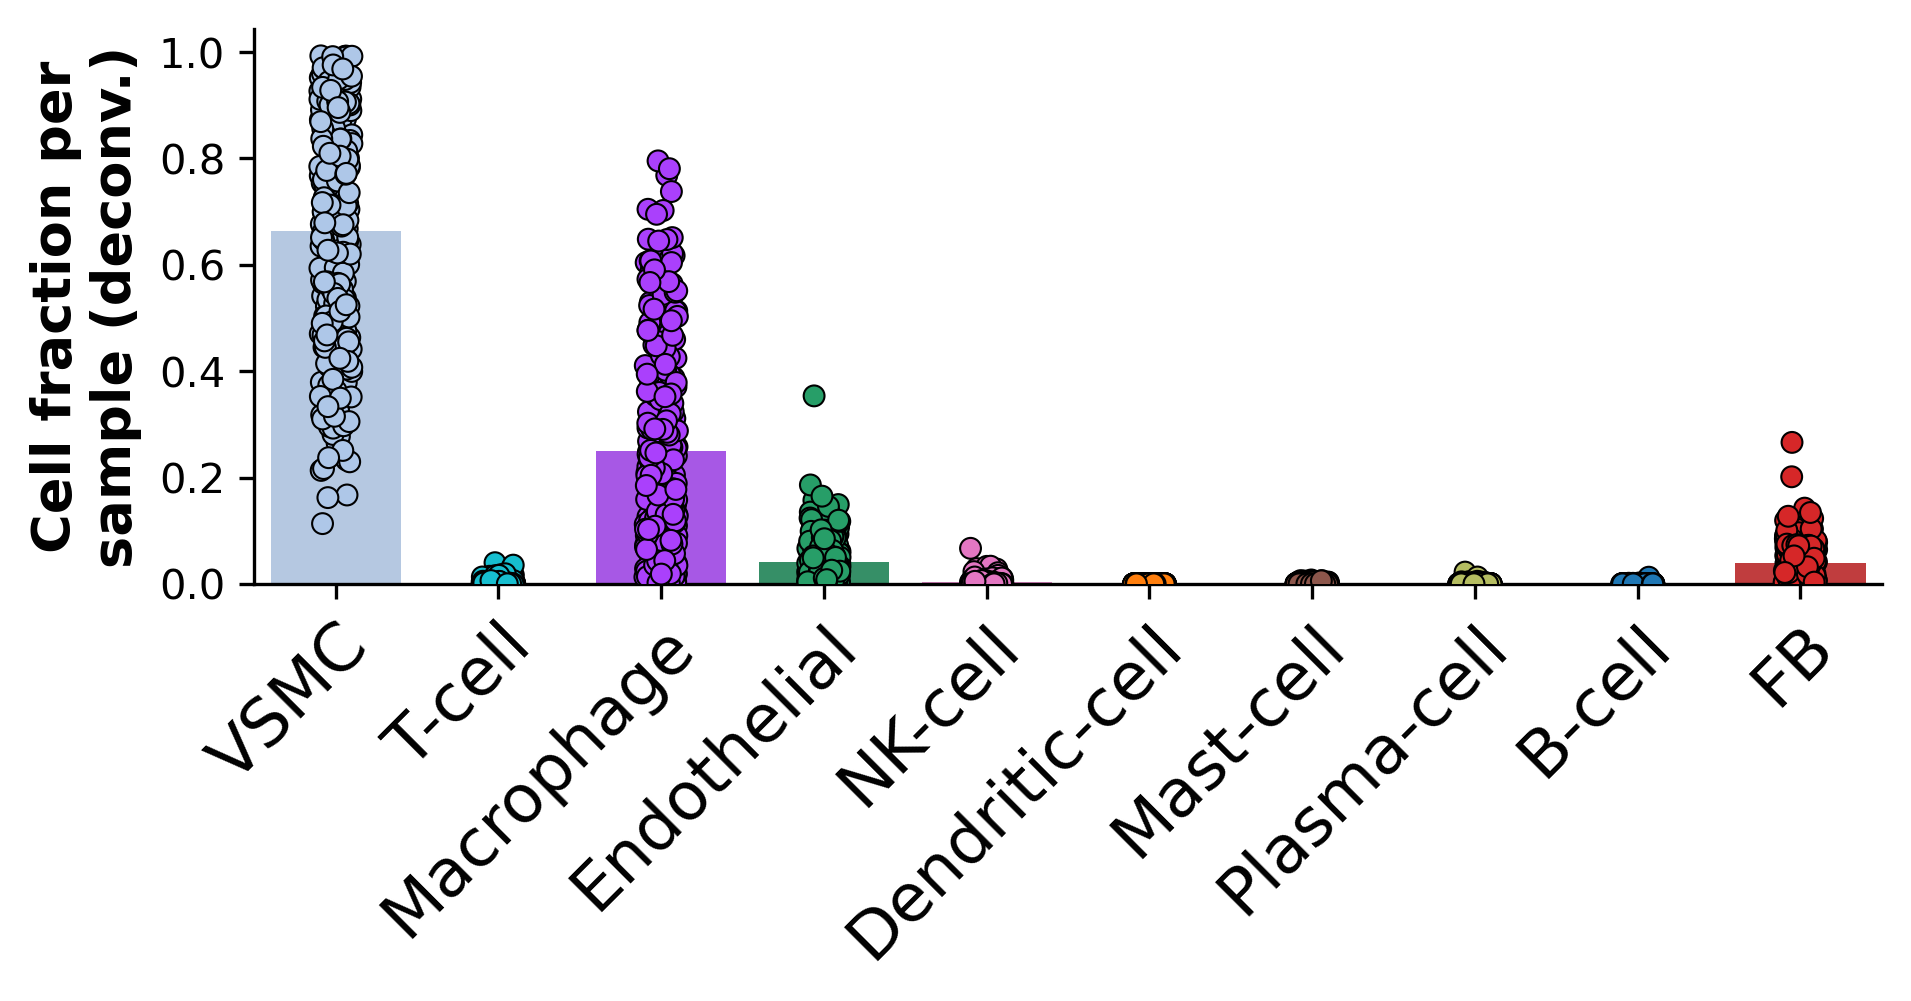

In [18]:
bulk_cell_fractions=pd.read_csv('../../../data/sa_for_Daniel.csv',index_col=0)
plot_df = bulk_cell_fractions[[*color_palette]].mean().reset_index()
#plot_df.columns=['Celltype','proportion']
plot_df = bulk_cell_fractions[[*color_palette]]

#for met_coln_title,met_coln in zip(met_coln_titles,met_colnames):

fig,ax=plt.subplots(1,1,figsize=(7,2.4))
#fig.suptitle('Bulk RNA-seq',fontsize=14,fontweight='bold')

sns.barplot(data=plot_df,#.reset_index(),
            #x='Celltype',
            #y='proportion',
            color='dodgerblue',#alpha=0.7,
            order=hue_order,
           palette=color_palette)

sns.stripplot(data=plot_df.melt(),
                    x='variable',
                    y='value',color='dodgerblue',#alpha=0.7,
                     order=hue_order,
                    edgecolor='black',
                      linewidth=0.5,
                    palette=color_palette)

#ax.set_ylim(None,np.quantile(plot_df[met_coln],1))

# Rotate x-axis tick labels by 45 degrees
x_ticks=[label.get_text().replace('_mixed_cell','\nmixed_cell') for label in ax.get_xticklabels()]
x_ticks=[label.replace(r'/','/\n') for label in x_ticks]
ax.set_xticklabels(x_ticks)
plt.xticks(rotation=45,fontsize=16,ha='right', rotation_mode='anchor')

ax.set_ylabel('Cell fraction from\ndeconvolution',fontsize=14,fontweight='bold')
ax.set_ylabel('Cell fraction per\nsample (deconv.)',fontsize=13,fontweight='bold')
ax.set_xlabel(None)
ax.spines[['top','right']].set_visible(False)


## SAvefig    
proc_dir='../../xenium_data/processed_data/baysor_processed_output'
os.makedirs(os.path.join(proc_dir,'figure_plots','Fig2','cell_counts'),exist_ok=True)
fn=os.path.join(proc_dir,'figure_plots','Fig2','cell_counts',f'bulk_cell_proportions.png')
fig.savefig(fn, dpi=300, bbox_inches='tight')
